In [2]:
from statsbombpy import sb
import pandas as pd
from mplsoccer import Pitch,Sbopen
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display

In [ ]:
#pip install highlight-text

  Using cached highlight_text-0.2-py3-none-any.whl.metadata (13 kB)
Using cached highlight_text-0.2-py3-none-any.whl (11 kB)
Note: you may need to restart the kernel to use updated packages.


In [ ]:
#pip install cmasher

  Using cached colorspacious-1.1.2-py2.py3-none-any.whl.metadata (3.6 kB)
Using cached colorspacious-1.1.2-py2.py3-none-any.whl (37 kB)

   ---------------------------------------- 0/2 [colorspacious]
   -------------------- ------------------- 1/2 [cmasher]
   ---------------------------------------- 2/2 [cmasher]

Note: you may need to restart the kernel to use updated packages.


In [5]:
from urllib.request import urlopen
import warnings

import cmasher as cmr
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from highlight_text import ax_text

from mplsoccer import Pitch, VerticalPitch, add_image, FontManager, Sbopen

In [6]:
comps = sb.competitions()
comps['competition_name'].unique()

array(['1. Bundesliga', 'African Cup of Nations', 'Champions League',
       'Copa America', 'Copa del Rey', "FA Women's Super League",
       'FIFA U20 World Cup', 'FIFA World Cup', 'Indian Super league',
       'La Liga', 'Liga Profesional', 'Ligue 1', 'Major League Soccer',
       'North American League', 'NWSL', 'Premier League', 'Serie A',
       'UEFA Euro', 'UEFA Europa League', "UEFA Women's Euro",
       "Women's World Cup"], dtype=object)

In [7]:
comps[comps['competition_name']=='UEFA Euro']

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
68,55,282,Europe,UEFA Euro,male,False,True,2024,2024-09-28T16:51:20.698794,2025-03-24T14:12:30.785094,2025-03-24T14:12:30.785094,2024-09-28T16:51:20.698794
69,55,43,Europe,UEFA Euro,male,False,True,2020,2024-07-31T12:29:15.702309,2024-07-31T12:30:57.587087,2024-07-31T12:30:57.587087,2024-07-31T12:29:15.702309


In [8]:
matches = sb.matches(competition_id=55, season_id=43)
matches[matches['home_team']=='Italy']

,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,...,last_updated_360,match_week,competition_stage,stadium,referee,home_managers,away_managers,data_version,shot_fidelity_version,xy_fidelity_version
2,3788766,2021-06-20,18:00:00.000,Europe - UEFA Euro,2020,Italy,Wales,1,0,available,...,2023-04-27T22:22:42.769375,3,Group Stage,Estadio Olímpico,Ovidiu Alin Hațegan,Roberto Mancini,Robert Page,1.1.0,2,2
3,3795220,2021-07-06,21:00:00.000,Europe - UEFA Euro,2020,Italy,Spain,1,1,available,...,2022-08-04T12:00,6,Semi-finals,Wembley Stadium,Felix Brych,Roberto Mancini,Luis Enrique Martínez García,1.1.0,2,2
8,3788754,2021-06-16,21:00:00.000,Europe - UEFA Euro,2020,Italy,Switzerland,3,0,available,...,2023-04-27T22:33:19.992088,2,Group Stage,Estadio Olímpico,Sergey Karasev,Roberto Mancini,Vladimir Petković,1.1.0,2,2
16,3795506,2021-07-11,21:00:00.000,Europe - UEFA Euro,2020,Italy,England,1,1,available,...,2022-08-04T12:00,7,Final,Wembley Stadium,Björn Kuipers,Roberto Mancini,Gareth Southgate,1.1.0,2,2
21,3794685,2021-06-26,21:00:00.000,Europe - UEFA Euro,2020,Italy,Austria,2,1,available,...,2023-04-27T22:07:23.951045,4,Round of 16,Wembley Stadium,Anthony Taylor,Roberto Mancini,Franco Foda,1.1.0,2,2


In [ ]:
event = sb.events(match_id =3795220)
event
#list(event)

['ball_receipt_outcome',
 'ball_recovery_recovery_failure',
 'block_offensive',
 'carry_end_location',
 'clearance_aerial_won',
 'clearance_body_part',
 'clearance_head',
 'clearance_left_foot',
 'clearance_right_foot',
 'counterpress',
 'dribble_nutmeg',
 'dribble_outcome',
 'dribble_overrun',
 'duel_outcome',
 'duel_type',
 'duration',
 'foul_committed_advantage',
 'foul_committed_card',
 'foul_won_advantage',
 'foul_won_defensive',
 'goalkeeper_body_part',
 'goalkeeper_end_location',
 'goalkeeper_outcome',
 'goalkeeper_position',
 'goalkeeper_technique',
 'goalkeeper_type',
 'id',
 'index',
 'injury_stoppage_in_chain',
 'interception_outcome',
 'location',
 'match_id',
 'minute',
 'off_camera',
 'out',
 'pass_aerial_won',
 'pass_angle',
 'pass_assisted_shot_id',
 'pass_body_part',
 'pass_cross',
 'pass_cut_back',
 'pass_deflected',
 'pass_end_location',
 'pass_goal_assist',
 'pass_height',
 'pass_inswinging',
 'pass_length',
 'pass_no_touch',
 'pass_outcome',
 'pass_outswinging',
 '

In [10]:
parser = Sbopen()
events,related,freeze, tactics = parser.event(3795220)
lineup = parser.lineup(3795220)
lineup

,player_id,player_name,player_nickname,jersey_number,match_id,team_id,team_name,country_id,country_name
0,3166,Marco Verratti,Marco Verratti,6,3795220,914,Italy,112,Italy
1,4355,Emerson Palmieri dos Santos,Emerson,13,3795220,914,Italy,112,Italy
2,6954,Giorgio Chiellini,Giorgio Chiellini,3,3795220,914,Italy,112,Italy
3,6957,Alex Meret,Alex Meret,26,3795220,914,Italy,112,Italy
4,6964,Alessandro Florenzi,Alessandro Florenzi,24,3795220,914,Italy,112,Italy
5,6993,Bryan Cristante,Bryan Cristante,16,3795220,914,Italy,112,Italy
6,7002,Rafael Tolói,Rafael Tolói,25,3795220,914,Italy,112,Italy
7,7024,Jorge Luiz Frello Filho,Jorginho,8,3795220,914,Italy,112,Italy
8,7036,Gianluigi Donnarumma,Gianluigi Donnarumma,21,3795220,914,Italy,112,Italy
9,7037,Lorenzo Insigne,Lorenzo Insigne,10,3795220,914,Italy,112,Italy


In [11]:
# df with player_id and subbed off time
time_off = events.loc[(events.type_name == 'Substitution'),
                      ['player_id', 'minute']]
time_off.rename({'minute': 'off'}, axis='columns', inplace=True)
# df with player_id and subbed on time
time_on = events.loc[(events.type_name == 'Substitution'),
                     ['substitution_replacement_id', 'minute']]
time_on.rename({'substitution_replacement_id': 'player_id',
                'minute': 'on'}, axis='columns', inplace=True)
players_on = time_on.player_id
# merge on times subbed on/off
lineup = lineup.merge(time_on, on='player_id', how='left')
lineup = lineup.merge(time_off, on='player_id', how='left')
lineup

,player_id,player_name,player_nickname,jersey_number,match_id,team_id,team_name,country_id,country_name,on,off
0,3166,Marco Verratti,Marco Verratti,6,3795220,914,Italy,112,Italy,NaN,73.0
1,4355,Emerson Palmieri dos Santos,Emerson,13,3795220,914,Italy,112,Italy,NaN,73.0
2,6954,Giorgio Chiellini,Giorgio Chiellini,3,3795220,914,Italy,112,Italy,NaN,NaN
3,6957,Alex Meret,Alex Meret,26,3795220,914,Italy,112,Italy,NaN,NaN
4,6964,Alessandro Florenzi,Alessandro Florenzi,24,3795220,914,Italy,112,Italy,NaN,NaN
5,6993,Bryan Cristante,Bryan Cristante,16,3795220,914,Italy,112,Italy,NaN,NaN
6,7002,Rafael Tolói,Rafael Tolói,25,3795220,914,Italy,112,Italy,73.0,NaN
7,7024,Jorge Luiz Frello Filho,Jorginho,8,3795220,914,Italy,112,Italy,NaN,NaN
8,7036,Gianluigi Donnarumma,Gianluigi Donnarumma,21,3795220,914,Italy,112,Italy,NaN,NaN
9,7037,Lorenzo Insigne,Lorenzo Insigne,10,3795220,914,Italy,112,Italy,NaN,84.0


In [13]:
# filtering the Italy lineup
# assigning Spain as team 2

team1, team2 = lineup.team_name.unique()  # Italy (team1), Spain (team2)
team = team1
lineup_team = lineup[lineup.team_name == team].copy()

# filter the events to exclude some set pieces
set_pieces = ['Throw-in', 'Free Kick', 'Corner', 'Kick Off', 'Goal Kick']
# for the team pass map
pass_receipts = events[(events.team_name == team) & (events.type_name == 'Ball Receipt')].copy()
# for the player pass maps
passes_excl_throw = events[(events.team_name == team) & (events.type_name == 'Pass') &
                           (events.sub_type_name != 'Throw-in')].copy()

# identify how many players played and how many subs were used
# we will use this in the loop for only plotting pass maps for as
# many players who played
num_players = len(lineup_team)
num_sub = num_players - 11

pass_receipts
num_players
num_sub

12

In [16]:
# add padding to the top so we can plot the titles, and raise the pitch lines
pitch = Pitch(pad_top=10, line_zorder=2)

# arrow properties for the sub on/off
green_arrow = dict(arrowstyle='simple, head_width=0.7',
                   connectionstyle="arc3,rad=-0.8", fc="green", ec="green")
red_arrow = dict(arrowstyle='simple, head_width=0.7',
                 connectionstyle="arc3,rad=-0.8", fc="red", ec="red")

# a fontmanager object for using a google font
fm_scada = FontManager('https://raw.githubusercontent.com/googlefonts/scada/main/fonts/ttf/'
                       'Scada-Regular.ttf')

SB_LOGO_URL = ('https://raw.githubusercontent.com/statsbomb/open-data/'
               'master/img/SB%20-%20Icon%20Lockup%20-%20Colour%20positive.png')

sb_logo = Image.open(urlopen(SB_LOGO_URL))
spain = Image.open('sp.png')
italy = Image.open('ita.png')

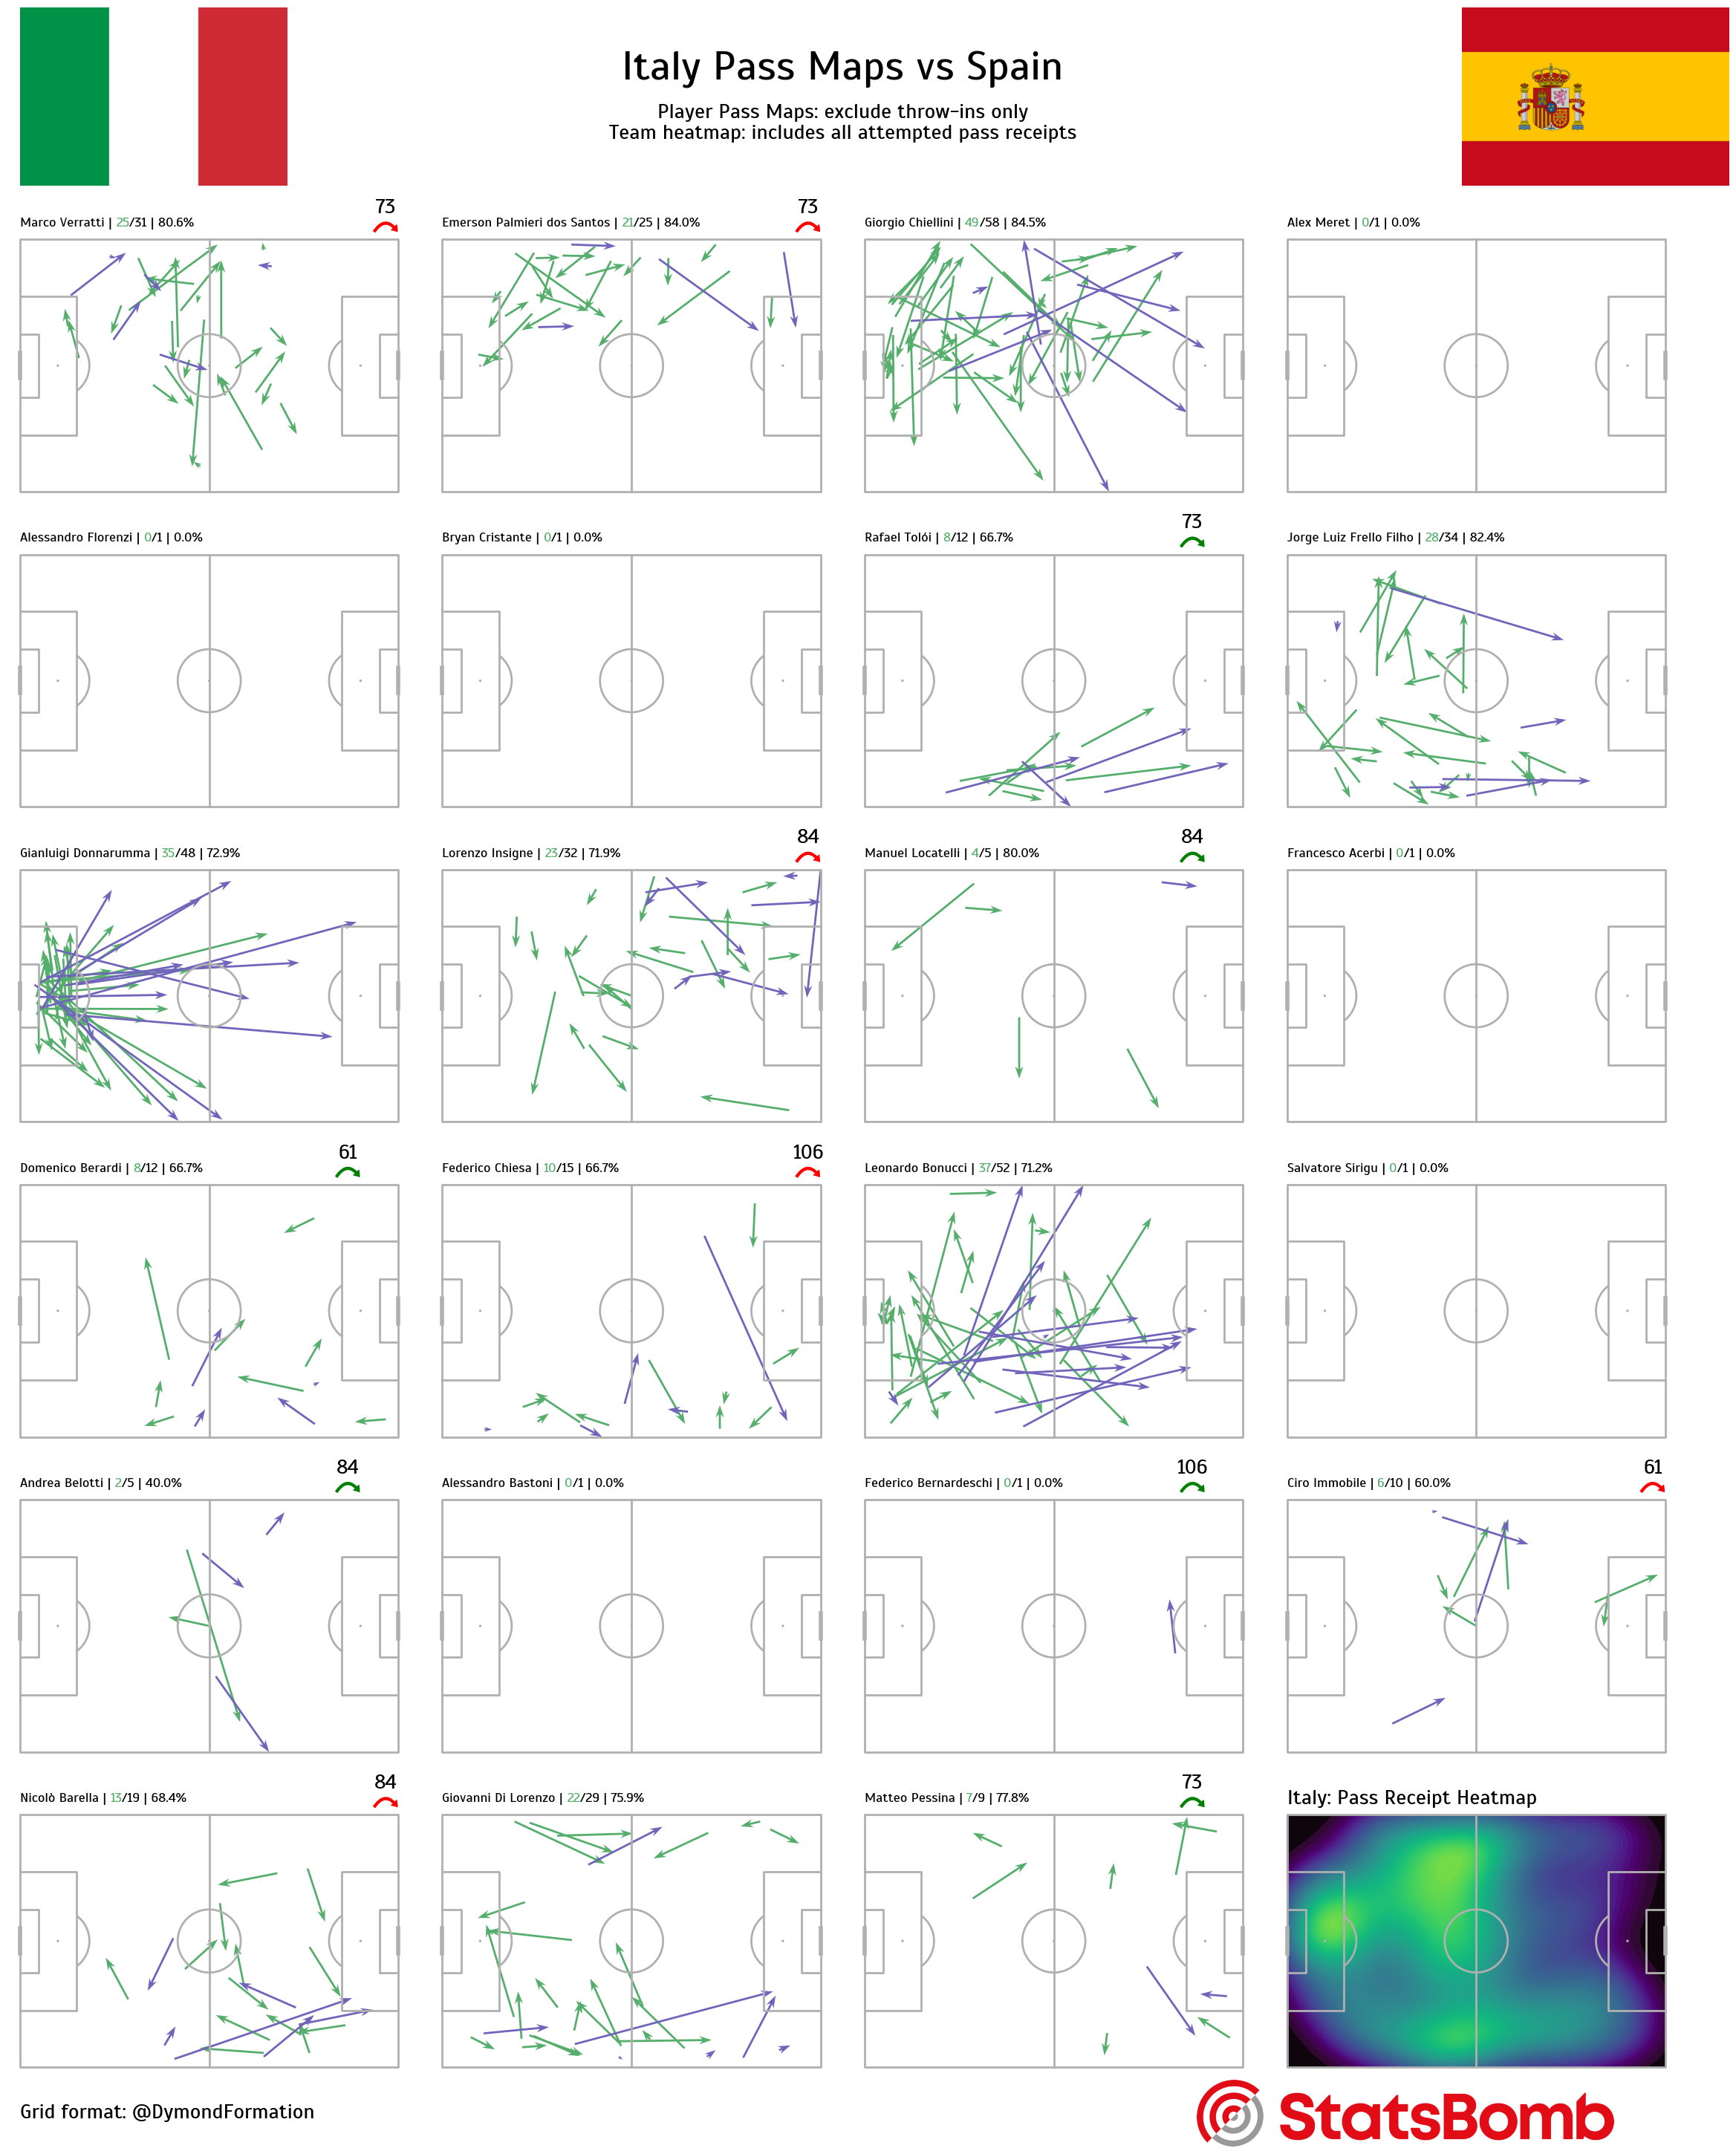

In [17]:
import warnings

# Filtering out some highlight_text warnings - the warnings aren't correct as the
# text fits inside the axes.
warnings.simplefilter("ignore", UserWarning)

# Plot the 7 * 3 grid
fig, axs = pitch.grid(nrows=6, ncols=4, figheight=30,
                      endnote_height=0.03, endnote_space=0,
                      axis=False,
                      title_height=0.08, grid_height=0.84)

# Plot the player pass maps
for idx, ax in enumerate(axs['pitch'].flat):
    # Plot the pass maps up to the total number of players
    if idx < num_players:
        # Filter the complete/incomplete passes for each player excluding throw-ins
        lineup_player = lineup_team.iloc[idx]
        player_id = lineup_player.player_id
        player_pass = passes_excl_throw[passes_excl_throw.player_id == player_id]
        complete_pass = player_pass[player_pass.outcome_name.isnull()]
        incomplete_pass = player_pass[player_pass.outcome_name.notnull()]

        # Plot the arrows
        pitch.arrows(complete_pass.x, complete_pass.y,
                     complete_pass.end_x, complete_pass.end_y,
                     color='#56ae6c', width=2, headwidth=4, headlength=6, ax=ax)
        pitch.arrows(incomplete_pass.x, incomplete_pass.y,
                     incomplete_pass.end_x, incomplete_pass.end_y,
                     color='#7065bb', width=2, headwidth=4, headlength=6, ax=ax)

        # Calculate total passes
        total_pass = len(complete_pass) + len(incomplete_pass)
        if total_pass == 0:
            total_pass = 1  # Ensure denominator is not zero

        # Build annotation string
        annotation_string = (f'{lineup_player.player_name} | '
                             f'<{len(complete_pass)}>/{total_pass} | ')
        if total_pass != 0:
            annotation_string += f'{round(100 * len(complete_pass) / total_pass, 1)}%'

        # Add annotation to the plot
        ax_text(0, -5, annotation_string, ha='left', va='center', fontsize=13,
                fontproperties=fm_scada.prop,  # using the font manager for the Google font
                highlight_textprops=[{"color": '#56ae6c'}], ax=ax)

        # Add information for substitutions on/off and arrows
        if not np.isnan(lineup_team.iloc[idx].off):
            ax.text(116, -10, str(lineup_team.iloc[idx].off.astype(int)), fontsize=20,
                    fontproperties=fm_scada.prop,
                    ha='center', va='center')
            ax.annotate('', (120, -2), (112, -2), arrowprops=red_arrow)
        if not np.isnan(lineup_team.iloc[idx].on):
            ax.text(104, -10, str(lineup_team.iloc[idx].on.astype(int)), fontsize=20,
                    fontproperties=fm_scada.prop,
                    ha='center', va='center')
            ax.annotate('', (108, -2), (100, -2), arrowprops=green_arrow)

# Plot on the last Pass Map
# (Note ax=ax as we have cycled through to the last axes in the loop)
pitch.kdeplot(x=pass_receipts.x, y=pass_receipts.y, ax=ax,
              cmap=cmr.lavender,
              levels=100,
              thresh=0, fill=True)
ax.text(0, -5, f'{team}: Pass Receipt Heatmap', ha='left', va='center',
        fontsize=20, fontproperties=fm_scada.prop)

# Remove unused axes (if any)
for ax in axs['pitch'].flat[11 + num_sub:-1]:
    ax.remove()

# Endnote text
axs['endnote'].text(0, 0.5, 'Grid format: @DymondFormation',
                    fontsize=20, fontproperties=fm_scada.prop, va='center', ha='left')

# Add image
ax_sb_logo = add_image(sb_logo, fig, left=0.701126,
                       # Set the bottom and height to align with the endnote
                       bottom=axs['endnote'].get_position().y0,
                       height=axs['endnote'].get_position().height)

# Title text
axs['title'].text(0.5, 0.65, f'{team1} Pass Maps vs {team2}', fontsize=40,
                  fontproperties=fm_scada.prop, va='center', ha='center')
SUB_TEXT = ('Player Pass Maps: exclude throw-ins only\n'
            'Team heatmap: includes all attempted pass receipts')
axs['title'].text(0.5, 0.35, SUB_TEXT, fontsize=20,
                  fontproperties=fm_scada.prop, va='center', ha='center')

# Plot logos (same height as the title_ax)
# Set the Italy flag to align with the left/bottom of the title axes
ax_italy_logo = add_image(italy, fig,
                          left=axs['title'].get_position().x0,
                          bottom=axs['title'].get_position().y0,
                          height=axs['title'].get_position().height)
# Set the Spain flag to align with the right/bottom of the title axes
ax_spain_logo = add_image(spain, fig, left=0.8521,
                          bottom=axs['title'].get_position().y0,
                          height=axs['title'].get_position().height)